# Spin-spin exchange mean field, including anisotropic exchange

Besides density-density interactions, pyqula solves a direct spin-spin coupling
$\vec S_i\cdot\vec S_j$ at the mean-field level:

$$
H = J_z\sum_{\langle ij\rangle} S^z_i S^z_j
+ J_x\sum_{\langle ij\rangle} S^x_i S^x_j
+ J_y\sum_{\langle ij\rangle} S^y_i S^y_j
$$

`h.get_szsz_mean_field_hamiltonian(J1=...)` solves the $S^zS^z$ channel directly (it is a
density-density interaction between spin-orbitals); `get_sxsx_mean_field_hamiltonian`/
`get_sysy_mean_field_hamiltonian` solve the same problem after a global spin rotation. All three
can be combined into a single anisotropic-exchange loop with
`get_exchange_mean_field_hamiltonian(Jx1=...,Jy1=...,Jz1=...)`, and combined further with ordinary
density-density interactions ($U$, $V_1$, ...) in one selfconsistent loop with
`get_combined_mean_field_hamiltonian(U=...,J1=...,...)`.

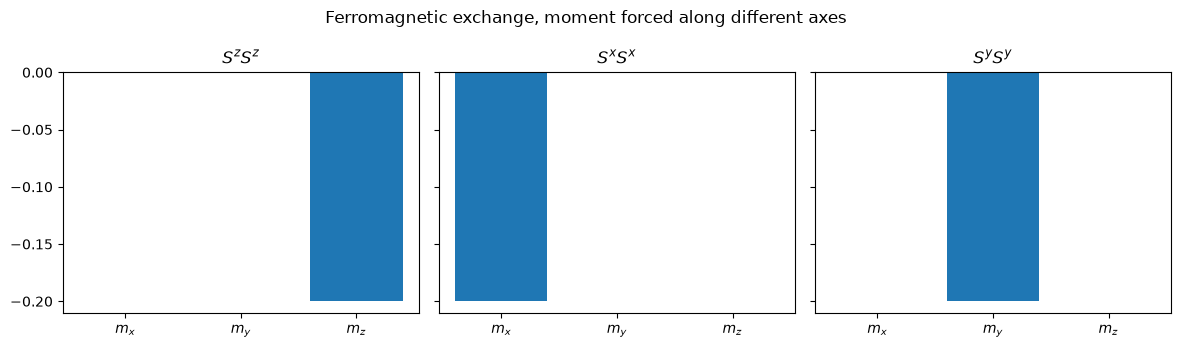

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
g = geometry.chain() # a chain, prone to ferromagnetic order away from half filling

fast = dict(nk=10,maxerror=1e-6,mix=0.3,maxite=300,filling=0.2) # converges in ~1s; the
                                                                  # default mix is very slow here

def converged_moment(mf_axis):
    h = g.get_hamiltonian(has_spin=True)
    if mf_axis=="z": h = h.get_szsz_mean_field_hamiltonian(J1=-2.0,mf="ferroZ",**fast)
    elif mf_axis=="x": h = h.get_sxsx_mean_field_hamiltonian(J1=-2.0,mf="ferroX",**fast)
    elif mf_axis=="y": h = h.get_sysy_mean_field_hamiltonian(J1=-2.0,mf="ferroY",**fast)
    return h.get_magnetization()

mz = converged_moment("z")
mx = converged_moment("x")
my = converged_moment("y")

fig,axs = plt.subplots(1,3,figsize=(12,3.5),sharey=True)
for ax,m,label in zip(axs,[mz,mx,my],["$S^zS^z$","$S^xS^x$","$S^yS^y$"]):
    ax.bar(["$m_x$","$m_y$","$m_z$"],np.mean(m,axis=0))
    ax.set_title(label)
plt.suptitle("Ferromagnetic exchange, moment forced along different axes")
plt.tight_layout()
plt.show()

The spectral function projected on the spin along the axis of the exchange shows what the three
channels have in common: in each of them the ferromagnetic exchange splits the band into a
majority and a minority copy with opposite spin, along $z$, $x$ or $y$ respectively, so that the
three self-consistent states are the same ferromagnet rotated in spin space.

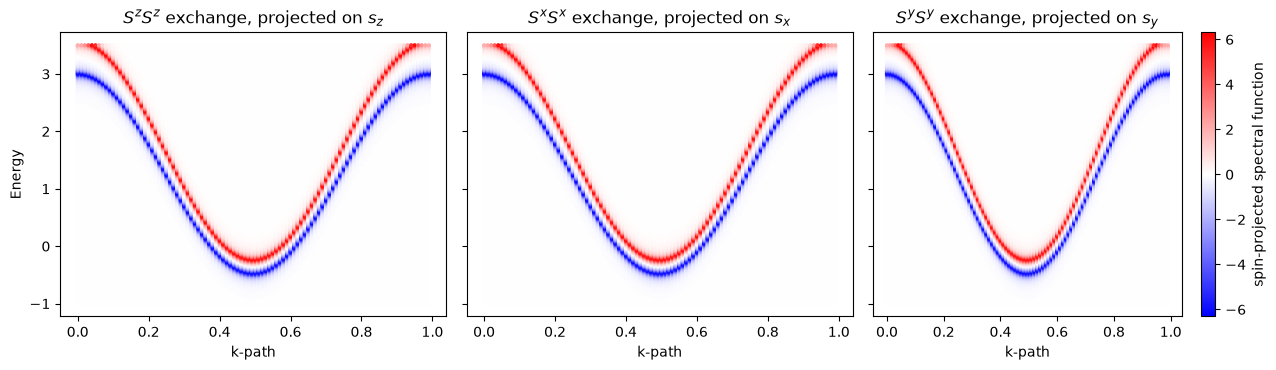

In [2]:
def converged_hamiltonian(mf_axis):
    h = g.get_hamiltonian(has_spin=True)
    if mf_axis=="z": return h.get_szsz_mean_field_hamiltonian(J1=-2.0,mf="ferroZ",**fast)
    elif mf_axis=="x": return h.get_sxsx_mean_field_hamiltonian(J1=-2.0,mf="ferroX",**fast)
    elif mf_axis=="y": return h.get_sysy_mean_field_hamiltonian(J1=-2.0,mf="ferroY",**fast)

energies = np.linspace(-1.,3.5,200) # the Fermi energy is at zero
fig,axs = plt.subplots(1,3,figsize=(13,3.8),sharey=True)
for ax,axis in zip(axs,["z","x","y"]):
    h = converged_hamiltonian(axis)
    (k,e,d) = h.get_kdos_bands(operator="s"+axis,energies=energies,delta=5e-2) # spin-projected spectral function
    dmax = np.max(np.abs(d)) # symmetric color scale
    sc = ax.scatter(k,e,c=d,cmap="bwr",vmin=-dmax,vmax=dmax,s=4)
    ax.set_title(f"$S^{axis}S^{axis}$ exchange, projected on $s_{axis}$")
    ax.set_xlabel("k-path")
axs[0].set_ylabel("Energy")
plt.colorbar(sc,ax=axs[-1],label="spin-projected spectral function")
plt.tight_layout()
plt.show()

Density-density interactions ($U$/$V_1$/...) and exchange ($J$) can also be
converged together in a single combined SCF loop:

In [3]:
h = g.get_hamiltonian(has_spin=True)
h = h.get_combined_mean_field_hamiltonian(U=2.0,J1=-1.0,mf="ferroZ",**fast)
m = h.get_magnetization()
print("Combined U+J converged moment per site:",np.mean(m,axis=0))

Combined U+J converged moment per site: [ 0.   0.  -0.2]
